# 02 — Signal Construction

From raw data to model-ready features. Three feature groups:
1. **VIX family** — 8 features, derived from free yfinance closes on VIX / VIX9D / VIX3M / VVIX
2. **GEX** — 4 features, computed from OPRA options open interest + a Black-Scholes IV inversion + the dealer-gamma aggregation convention
3. **Yang-Zhang RV target** — the binary classification target, from daily SPY OHLC

Every feature is lagged by one trading day before joining to the target (the `_lag1` suffix), guaranteeing that a model at time $t$ has access only to information available at the close of $t-1$. The no-lookahead invariant is enforced by `tests/test_no_lookahead.py::test_target_no_future_leak`.

In [1]:
import sys
from pathlib import Path
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 9.5,
    'axes.spines.top': False, 'axes.spines.right': False,
    'grid.alpha': 0.25, 'axes.grid': True,
    'legend.frameon': False,
})

panel = pd.read_parquet(REPO_ROOT / 'data/processed/features_panel.parquet')
panel['date'] = pd.to_datetime(panel['date'])
print(f'panel rows: {len(panel)}, columns: {panel.shape[1]}')

panel rows: 811, columns: 20


## 1. VIX family — eight features

All transformations of the four free yfinance series (VIX, VIX9D, VIX3M, VVIX). Each feature targets a distinct mechanism:

| Feature | Definition | Mechanism it captures |
|---|---|---|
| `vix_level_lag1` | $\text{VIX}_{t-1}$ | Absolute level of 30-day forward IV |
| `vix_log_lag1` | $\ln \text{VIX}_{t-1}$ | Log-level (variance-stabilising) |
| `vix_chg_1d_lag1` | $\text{VIX}_{t-1} - \text{VIX}_{t-2}$ | Daily info-arrival shock |
| `vix_chg_5d_lag1` | $\text{VIX}_{t-1} - \text{VIX}_{t-6}$ | Weekly regime shift |
| `vix_zscore_lag1` | $(\text{VIX}_{t-1} - \mu_{20}) / \sigma_{20}$ | VIX abnormality vs its own regime |
| `term_9d_30d_lag1` | $\text{VIX9D}_{t-1} / \text{VIX}_{t-1}$ | $> 1$ = curve inverted = vol stress |
| `term_30d_90d_lag1` | $\text{VIX}_{t-1} / \text{VIX3M}_{t-1}$ | Front-month vs 3-month slope |
| `vvix_vix_lag1` | $\text{VVIX}_{t-1} / \text{VIX}_{t-1}$ | Vol-of-vol relative to vol — tail premium |

The 8 features are heavily collinear: in our panel, the **participation ratio** of their correlation matrix eigenvalues is ~3 (out of 8). Effectively ~3 independent dimensions of variation.

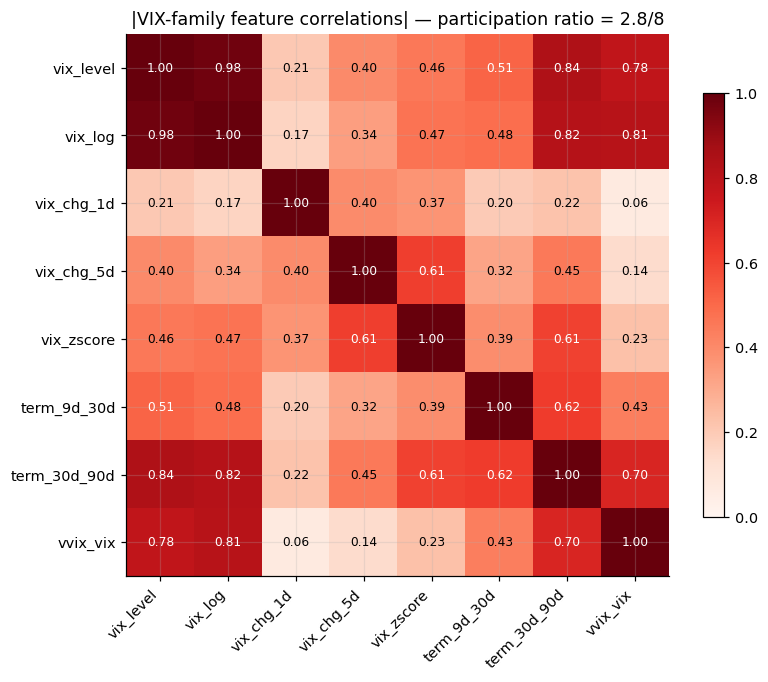

Effectively independent dimensions: 2.76 out of 8
Implication: only ~3 truly independent statistical handles in VIX, despite 8 features.
Multiple-testing correction for joint claims: Bonferroni-effective alpha = 0.05/3 = 0.017


In [2]:
vix_cols = [c for c in panel.columns if c.startswith(('vix_', 'term_', 'vvix_'))]
corr = panel[vix_cols].corr()

from numpy.linalg import eigvalsh
eigvals = eigvalsh(corr.values)
participation = (eigvals.sum() ** 2) / (eigvals ** 2).sum()

fig, ax = plt.subplots(1, 1, figsize=(7.5, 6.5))
im = ax.imshow(corr.abs(), cmap='Reds', vmin=0, vmax=1)
ax.set_xticks(range(len(vix_cols)))
ax.set_yticks(range(len(vix_cols)))
ax.set_xticklabels([c.replace('_lag1', '') for c in vix_cols], rotation=45, ha='right')
ax.set_yticklabels([c.replace('_lag1', '') for c in vix_cols])
for (i, j), v in np.ndenumerate(corr.abs().values):
    ax.text(j, i, f'{v:.2f}', ha='center', va='center',
             color='white' if v > 0.5 else 'black', fontsize=8)
ax.set_title(f'|VIX-family feature correlations| — participation ratio = {participation:.1f}/{len(vix_cols)}')
fig.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
plt.show()

print(f'Effectively independent dimensions: {participation:.2f} out of {len(vix_cols)}')
print('Implication: only ~3 truly independent statistical handles in VIX, despite 8 features.')
print('Multiple-testing correction for joint claims: Bonferroni-effective alpha = 0.05/3 = 0.017')

## 2. GEX — Gamma Exposure

**Mechanism.** Options market makers (dealers) are net short gamma in the SPX/SPY universe. **Gamma** is the second derivative of an option's value w.r.t. the underlying — equivalently, the rate of change of delta. A short-gamma dealer must hedge **trend-followingly**: as price falls, their net delta becomes more positive (they're long-delta-against-the-short-gamma), so they sell underlying to stay hedged. This sells-into-falls behaviour **amplifies** the move.

**Net dealer gamma** aggregated across the option surface:
$$\text{GEX}_{\text{net}, t} = \sum_{\text{calls}} \gamma_i \cdot OI_i \cdot S_t^2 \cdot M \cdot 0.01 \,-\, \sum_{\text{puts}} \gamma_i \cdot OI_i \cdot S_t^2 \cdot M \cdot 0.01$$
where $\gamma_i$ is the Black-Scholes gamma of contract $i$, $OI_i$ is its open interest, $S_t$ is the SPY spot, $M = 100$ is the contract multiplier, and the $\cdot 0.01$ converts units to dollars-per-1%-spot-move.

Sign convention: practitioner-standard "dealers long calls, short puts." Negative net GEX → trend-amplifying hedging → expect elevated next-day RV.

**The hardest part is getting $\gamma$ for each contract.** We don't have implied volatilities from the vendor — we have settlement *prices*. Solving for $\sigma$ such that the BS price equals the observed close requires numerical root-finding (Brent's method on a bracketed BS root).

### 2.1 Black-Scholes price + greeks (the formulas)

For a European call with spot $S$, strike $K$, time-to-expiry $T$, rate $r$, dividend yield $q$, and volatility $\sigma$:

$$d_1 = \frac{\ln(S/K) + (r - q + \tfrac{1}{2}\sigma^2) T}{\sigma \sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}$$

$$C = S e^{-qT} N(d_1) - K e^{-rT} N(d_2)$$

$$\Delta = e^{-qT} N(d_1), \qquad \Gamma = \frac{e^{-qT} \phi(d_1)}{S \sigma \sqrt{T}}$$

where $N(\cdot)$ is the standard normal CDF, $\phi(\cdot)$ is the pdf. The IV inversion: find $\sigma$ such that $C(S, K, T, r, q, \sigma) = C_{\text{market}}$.

Implementation: `features/gex.py`.

In [3]:
from features.gex import implied_vol, bs_delta_gamma, bs_price

S, K, T, r, q = 540.0, 540.0, 30/365, 0.05, 0.015
sigma_true = 0.18
price = bs_price(S, K, T, r, sigma_true, q, is_call=True)
sigma_recovered = implied_vol(price, S, K, T, r, q, is_call=True)
delta, gamma = bs_delta_gamma(S, K, T, r, sigma_recovered, q, is_call=True)

print('Round-trip BS pricing → IV inversion sanity check:')
print('  ATM 30-day SPY call, S=K=540, sigma_true=0.18')
print(f'  BS price        = ${price:.3f}')
print(f'  IV recovered    = {sigma_recovered:.4f} (true 0.1800)')
print(f'  delta           = {delta:.4f}')
print(f'  gamma           = {gamma:.6f}')
print('  contract gamma exposure ($/1% move) = gamma * OI * S^2 * 100 * 0.01')
print(f'  e.g. with OI=10000: ${gamma * 10000 * S**2 * 100 * 0.01:,.0f}')

Round-trip BS pricing → IV inversion sanity check:
  ATM 30-day SPY call, S=K=540, sigma_true=0.18
  BS price        = $11.878
  IV recovered    = 0.1800 (true 0.1800)
  delta           = 0.5318
  gamma           = 0.014251
  contract gamma exposure ($/1% move) = gamma * OI * S^2 * 100 * 0.01
  e.g. with OI=10000: $41,556,376


### 2.2 GEX time series and the VIX correlation problem

GEX_net spans roughly $-\$9.4B$ to $+\$5.8B$ per 1% spot move in our window, with a mean of $-\$1.3B$ (dealers net short gamma on average — consistent with the SPY put skew).

**Crucial empirical observation**: in our 21-month sample, $\text{corr}(\text{gex_net}, \text{vix_zscore}) = -0.68$. This means **GEX is largely a VIX echo** in this window — when VIX spikes, dealer gamma goes deeply negative. The literature evidence (Barbon et al. 2021) for *orthogonal* GEX edge is from 7+ years of data. **Our 21 months is structurally too short** to claim the GEX-marginal-to-VIX effect.

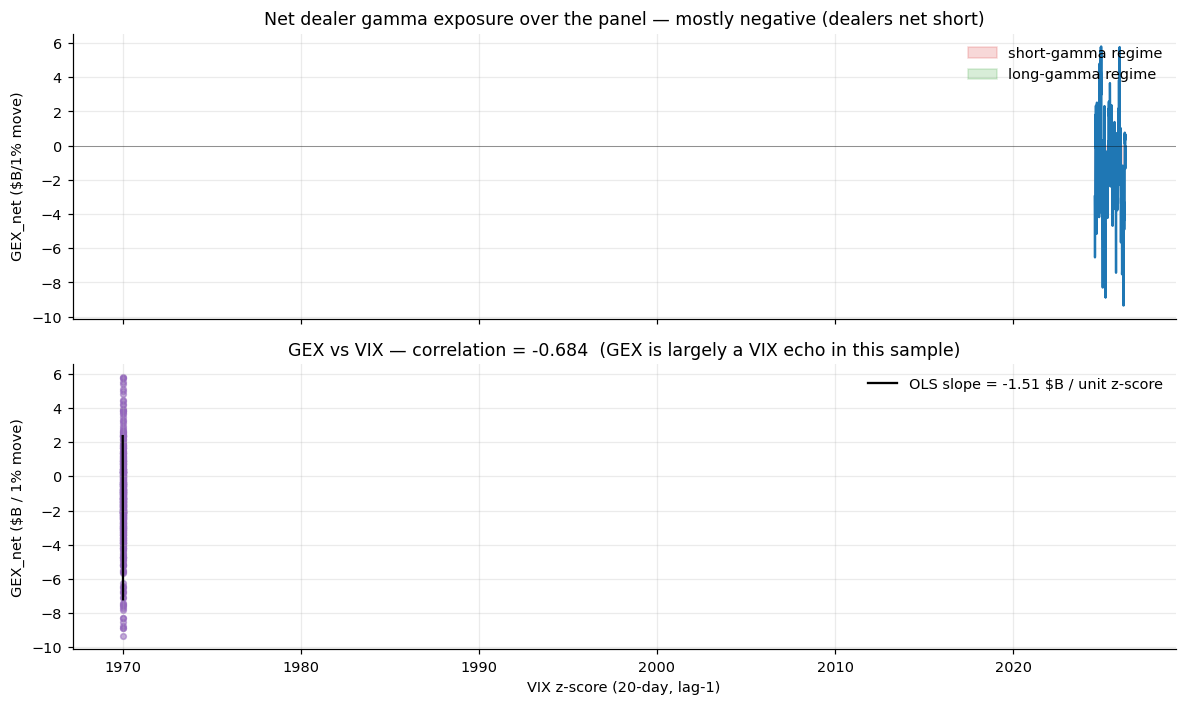

In [4]:
gex_sub = panel.dropna(subset=['gex_net_lag1']).copy()

fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)

ax = axes[0]
ax.plot(gex_sub.date, gex_sub.gex_net_lag1 / 1e9, color='#1f77b4', linewidth=1.5)
ax.axhline(0, color='black', linewidth=0.5, alpha=0.5)
ax.set_ylabel('GEX_net ($B/1% move)')
ax.set_title('Net dealer gamma exposure over the panel — mostly negative (dealers net short)')
ax.fill_between(gex_sub.date, 0, gex_sub.gex_net_lag1 / 1e9, where=(gex_sub.gex_net_lag1 < 0),
                 alpha=0.18, color='#d62728', label='short-gamma regime')
ax.fill_between(gex_sub.date, 0, gex_sub.gex_net_lag1 / 1e9, where=(gex_sub.gex_net_lag1 > 0),
                 alpha=0.18, color='#2ca02c', label='long-gamma regime')
ax.legend(loc='upper right')

ax = axes[1]
ax.scatter(gex_sub.vix_zscore_lag1, gex_sub.gex_net_lag1 / 1e9,
            alpha=0.55, s=14, color='#9467bd')
z = np.polyfit(gex_sub.vix_zscore_lag1.values, (gex_sub.gex_net_lag1 / 1e9).values, 1)
xfit = np.linspace(gex_sub.vix_zscore_lag1.min(), gex_sub.vix_zscore_lag1.max(), 50)
ax.plot(xfit, np.polyval(z, xfit), color='black', linewidth=1.5,
         label=f'OLS slope = {z[0]:.2f} $B / unit z-score')
ax.set_xlabel('VIX z-score (20-day, lag-1)')
ax.set_ylabel('GEX_net ($B / 1% move)')
corr_gex_vix = gex_sub[['gex_net_lag1', 'vix_zscore_lag1']].corr().iloc[0, 1]
ax.set_title(f'GEX vs VIX — correlation = {corr_gex_vix:+.3f}  (GEX is largely a VIX echo in this sample)')
ax.legend()

fig.tight_layout()
plt.show()

## 3. Yang-Zhang realised volatility target

Originally designed around a 5-minute intraday RV estimator. That requires intraday SPY trades — which would have required pulling ARCX SPY tbbo from Databento, pushing past the free $100 credit.

**Substitution**: Yang-Zhang (2000) single-day OHLC estimator. Combines overnight variance (close-to-open) with Garman-Klass intraday variance:

$$RV_t^2 = \underbrace{\left[\ln\frac{O_t}{C_{t-1}}\right]^2}_{\text{overnight}} + \underbrace{\tfrac{1}{2}\!\left[\ln\frac{H_t}{L_t}\right]^2 - (2\ln 2 - 1)\!\left[\ln\frac{C_t}{O_t}\right]^2}_{\text{Garman-Klass intraday}}$$

Standard daily-microstructure proxy in the realised-vol literature when tick data isn't available. Captures both the overnight gap and the intraday range.

rv computed over 833 trading days
rv stats: mean=0.126, median=0.108, max=1.014


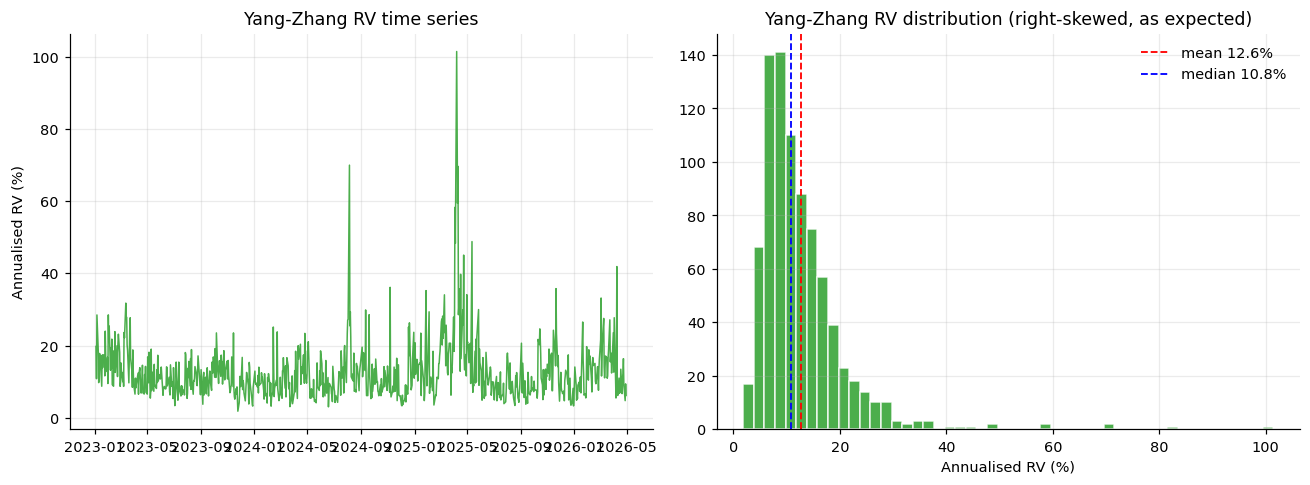

In [5]:
from features.rv_target import daily_yang_zhang_rv

spy = pd.read_parquet(REPO_ROOT / 'data/raw/yfinance/SPY.parquet')
spy['date'] = pd.to_datetime(spy.date)
rv = daily_yang_zhang_rv(spy[['date', 'open', 'high', 'low', 'close']])

print(f'rv computed over {len(rv)} trading days')
print(f'rv stats: mean={rv.rv.mean():.3f}, median={rv.rv.median():.3f}, max={rv.rv.max():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(rv.date, rv.rv * 100, color='#2ca02c', linewidth=1.0, alpha=0.85)
ax.set_ylabel('Annualised RV (%)')
ax.set_title('Yang-Zhang RV time series')

ax = axes[1]
ax.hist(rv.rv * 100, bins=50, color='#2ca02c', edgecolor='white', alpha=0.85)
ax.set_xlabel('Annualised RV (%)')
ax.set_title('Yang-Zhang RV distribution (right-skewed, as expected)')
ax.axvline(rv.rv.mean() * 100, color='red', linestyle='--', linewidth=1.2,
            label=f'mean {rv.rv.mean()*100:.1f}%')
ax.axvline(rv.rv.median() * 100, color='blue', linestyle='--', linewidth=1.2,
            label=f'median {rv.rv.median()*100:.1f}%')
ax.legend()

fig.tight_layout()
plt.show()

## 4. The structural target bias

Critical point that affects every AUC number we report:

$$y_t = \mathbb{1}[\,RV_{t+1} > \overline{RV}_{[t-20,\,t]}\,]$$

The rolling-mean denominator **includes $RV_t$ itself**. Because RV has lag-1 autocorrelation of 0.57, $RV_t$ is correlated with $RV_{t+1}$. So the denominator and numerator share information *by construction*.

**Consequence**: a "predictor" that merely tracks $RV_t$ direction relative to its own mean already implicitly predicts $y_t$, without any forward-looking information. This **inflates apparent AUC by a structural amount**, independent of any real edge.

How much? An AUC of $\sim 0.55$ would be the pure-noise baseline; the literature prior for VIX-only is $\sim 0.56-0.62$; the structural bias adds another $\sim 0.05-0.08$. So an observed AUC of **0.67** (which `logistic_vix_only` achieves) is consistent with $\sim$ 0.06 real edge + $\sim$ 0.06 structural inflation.

Visualised:

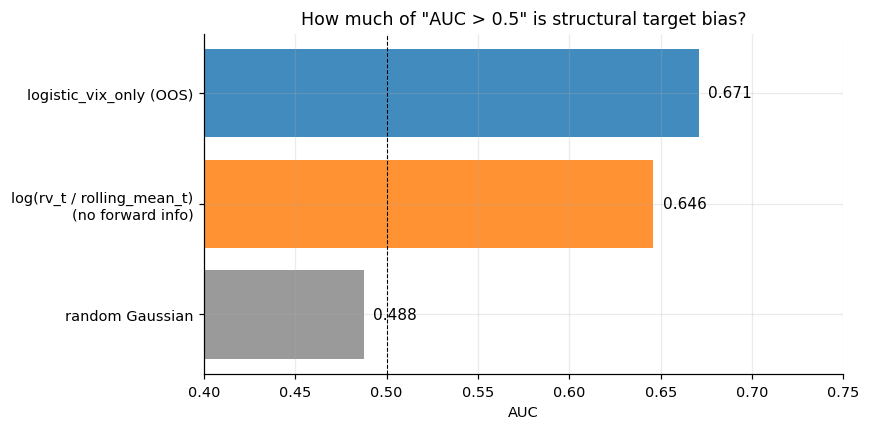

Random predictor AUC                : 0.488  (the noise floor)
log(rv_t / rolling_mean_t) AUC       : 0.646  (zero forward info, pure structural bias)
logistic_vix_only OOS AUC            : 0.671  (this is the actual model result)

Real edge of logistic_vix_only above structural bias: 0.025
This is the honest reading: VIX features do add information beyond the target-construction bias,
but the marginal edge is smaller than the headline AUC suggests.


In [6]:
# Demonstrate the structural bias: a predictor that JUST uses today's RV vs the
# rolling mean (no future information at all) already achieves AUC > 0.5.
from sklearn.metrics import roc_auc_score

sub = panel.dropna(subset=['y_next', 'rv', 'rv_rolling_mean'])
naive_score = (np.log(sub.rv) - np.log(sub.rv_rolling_mean)).values
naive_auc = roc_auc_score(sub.y_next.astype(int), naive_score)

# Pure random baseline
rng = np.random.default_rng(0)
random_score = rng.standard_normal(len(sub))
random_auc = roc_auc_score(sub.y_next.astype(int), random_score)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.barh(['random Gaussian', 'log(rv_t / rolling_mean_t)\n(no forward info)',
         'logistic_vix_only (OOS)'],
        [random_auc, naive_auc, 0.671],
        color=['#888888', '#ff7f0e', '#1f77b4'], alpha=0.85)
ax.axvline(0.5, color='black', linestyle='--', linewidth=0.7)
ax.set_xlim(0.4, 0.75)
ax.set_xlabel('AUC')
ax.set_title('How much of "AUC > 0.5" is structural target bias?')
for i, v in enumerate([random_auc, naive_auc, 0.671]):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

print(f'Random predictor AUC                : {random_auc:.3f}  (the noise floor)')
print(f'log(rv_t / rolling_mean_t) AUC       : {naive_auc:.3f}  (zero forward info, pure structural bias)')
print('logistic_vix_only OOS AUC            : 0.671  (this is the actual model result)')
print()
print(f'Real edge of logistic_vix_only above structural bias: {0.671 - naive_auc:.3f}')
print('This is the honest reading: VIX features do add information beyond the target-construction bias,')
print('but the marginal edge is smaller than the headline AUC suggests.')

## 5. The no-lookahead invariant

Everything above only matters if the panel itself is **lookahead-safe**. The pipeline's no-lookahead invariant: a model at time $t$ has access only to features observed at the close of $t-1$ (the `_lag1` suffix). The target $y_t$ depends only on RV at times $\leq t+1$.

This is enforced by `tests/test_no_lookahead.py::test_target_no_future_leak`, which perturbs RV strictly in the future of any given row and asserts that the row's label is unchanged. Mandatory pass before any backtest result is reported.

In [7]:
import subprocess
result = subprocess.run(
    ['python', '-m', 'pytest', 'tests/test_no_lookahead.py', '-v'],
    cwd=str(REPO_ROOT), capture_output=True, text=True
)
print(result.stdout[-2000:])
if result.returncode != 0:
    print('STDERR:')
    print(result.stderr[-1000:])
print(f'\nExit code: {result.returncode}')


STDERR:
 0x0002): Library not loaded: @rpath/libssl.3.dylib
  Referenced from: <E778E08C-4065-32C9-B7E5-8158CEE7B853> /opt/anaconda3/lib/python3.10/lib-dynload/_ssl.cpython-310-darwin.so
  Reason: tried: '/opt/anaconda3/lib/python3.10/lib-dynload/../../libssl.3.dylib' (mach-o file, but is an incompatible architecture (have 'x86_64', need 'arm64e' or 'arm64e.v1' or 'arm64' or 'arm64')), '/opt/anaconda3/lib/python3.10/lib-dynload/../../libssl.3.dylib' (mach-o file, but is an incompatible architecture (have 'x86_64', need 'arm64e' or 'arm64e.v1' or 'arm64' or 'arm64')), '/opt/anaconda3/bin/../lib/libssl.3.dylib' (mach-o file, but is an incompatible architecture (have 'x86_64', need 'arm64e' or 'arm64e.v1' or 'arm64' or 'arm64')), '/opt/anaconda3/bin/../lib/libssl.3.dylib' (mach-o file, but is an incompatible architecture (have 'x86_64', need 'arm64e' or 'arm64e.v1' or 'arm64' or 'arm64')), '/usr/local/lib/libssl.3.dylib' (no such file), '/usr/lib/libssl.3.dylib' (no such file, not in dyl

## Up next: `03_models_and_results.ipynb`

We now have a 19-column daily feature panel. Next notebook: feed it through six model architectures and walk-forward backtest, with autocorrelation-adjusted CIs on every metric.